## Exercício Prático 1.3: Análise Visual de Vendas com Pandas e Matplotlib para Guilherme Daflon

Este notebook é um guia direto para a Análise Visual de Vendas. Usaremos **Pandas** para manipular os dados e **Matplotlib** para as visualizações.

O objetivo: explorar padrões, tendências e obter insights dos dados de vendas. Vamos direto à análise para transformar os números em algo visual e compreensível.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Importação adicionada para uso do sns.barplot

# Criação de um dataset fictício de vendas
np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-06-30", freq="D")
produtos = ["Notebook", "Smartphone", "Fone de Ouvido", "Monitor"]

dados = {
    "Data": np.random.choice(datas, size=300),
    "Produto": np.random.choice(produtos, size=300, p=[0.2, 0.4, 0.25, 0.15]),
    "Quantidade": np.random.randint(1, 6, size=300),
    "Preco_Unitario": 0
}

df = pd.DataFrame(dados)

# Atribuindo preços de acordo com o produto
precos = {"Notebook": 3500, "Smartphone": 2000, "Fone de Ouvido": 150, "Monitor": 1200}
df["Preco_Unitario"] = df["Produto"].map(precos)

print("Dataset criado com sucesso! Primeiras linhas:")
display(df.head())

Dataset criado com sucesso! Primeiras linhas:


,Data,Produto,Quantidade,Preco_Unitario
0,2024-04-12,Monitor,3,1200
1,2024-06-28,Smartphone,1,2000
2,2024-04-02,Monitor,5,1200
3,2024-01-15,Fone de Ouvido,4,150
4,2024-04-16,Fone de Ouvido,1,150


### Tarefa 1: Faturamento por Produto

Vamos calcular o faturamento total por produto e visualizar os resultados.

In [13]:
# 1. Crie uma nova coluna chamada Faturamento_Total
df['Faturamento_Total'] = df['Quantidade'] * df['Preco_Unitario']

print("DataFrame com a nova coluna 'Faturamento_Total':")
display(df.head())

DataFrame com a nova coluna 'Faturamento_Total':


,Data,Produto,Quantidade,Preco_Unitario,Mes,Faturamento_Total
0,2024-04-12,Monitor,3,1200,2024-04,3600
1,2024-06-28,Smartphone,1,2000,2024-06,2000
2,2024-04-02,Monitor,5,1200,2024-04,6000
3,2024-01-15,Fone de Ouvido,4,150,2024-01,600
4,2024-04-16,Fone de Ouvido,1,150,2024-04,150


In [14]:
# 2. Agrupe os dados por Produto e calcule a soma do faturamento de cada um.
faturamento_por_produto = df.groupby('Produto')['Faturamento_Total'].sum().reset_index()

print("Faturamento total por produto:")
display(faturamento_por_produto)

Faturamento total por produto:


,Produto,Faturamento_Total
0,Fone de Ouvido,30150
1,Monitor,213600
2,Notebook,686000
3,Smartphone,626000


/tmp/ipykernel_1243/1345409402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Produto', y='Faturamento_Total', data=faturamento_por_produto, palette='viridis')


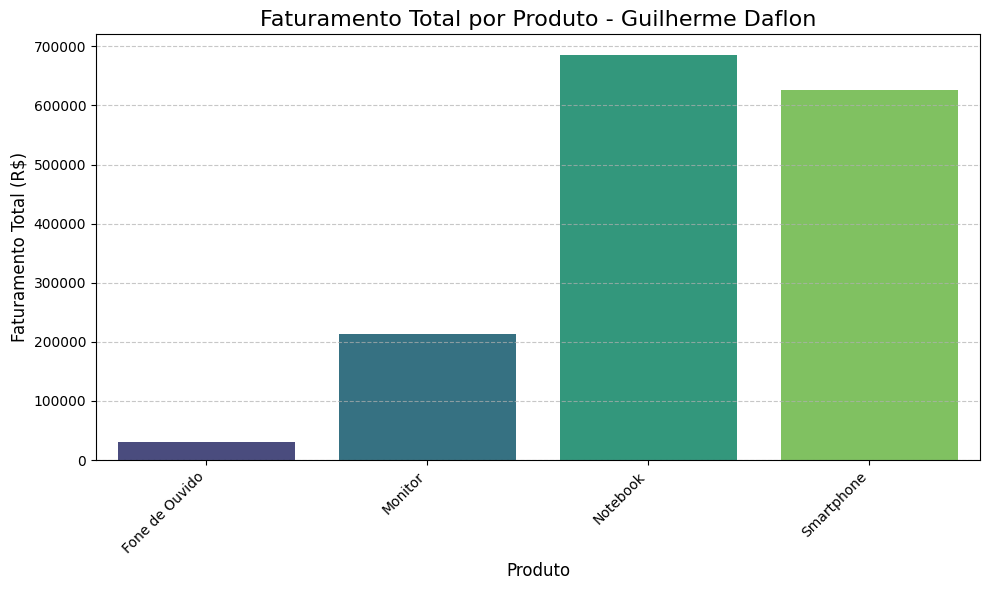

In [15]:
# 3. Gere um gráfico de barras mostrando o faturamento total por produto.
plt.figure(figsize=(10, 6))
sns.barplot(x='Produto', y='Faturamento_Total', data=faturamento_por_produto, palette='viridis')
plt.title('Faturamento Total por Produto - Guilherme Daflon', fontsize=16)
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo X para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

### Tarefa 2: Evolução das Vendas ao Longo do Tempo

Vamos analisar como as vendas se comportaram mês a mês.

In [16]:
# 1. Crie uma coluna extra chamada Mes extraindo o mês da coluna Data.
df['Mes'] = df['Data'].dt.to_period('M')

print("DataFrame com a nova coluna 'Mes':")
display(df.head())

DataFrame com a nova coluna 'Mes':


,Data,Produto,Quantidade,Preco_Unitario,Mes,Faturamento_Total
0,2024-04-12,Monitor,3,1200,2024-04,3600
1,2024-06-28,Smartphone,1,2000,2024-06,2000
2,2024-04-02,Monitor,5,1200,2024-04,6000
3,2024-01-15,Fone de Ouvido,4,150,2024-01,600
4,2024-04-16,Fone de Ouvido,1,150,2024-04,150


In [17]:
# 2. Agrupe os dados por mês para obter o total arrecadado por mês.
faturamento_por_mes = df.groupby('Mes')['Faturamento_Total'].sum().reset_index()

# Convertendo o período de volta para string para melhor visualização no gráfico
faturamento_por_mes['Mes'] = faturamento_por_mes['Mes'].astype(str)

print("Faturamento total por mês:")
display(faturamento_por_mes)

Faturamento total por mês:


,Mes,Faturamento_Total
0,2024-01,210300
1,2024-02,235950
2,2024-03,278450
3,2024-04,247650
4,2024-05,379650
5,2024-06,203750


/tmp/ipykernel_1243/601663741.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Mes', y='Faturamento_Total', data=faturamento_por_mes, marker='o', palette='viridis')


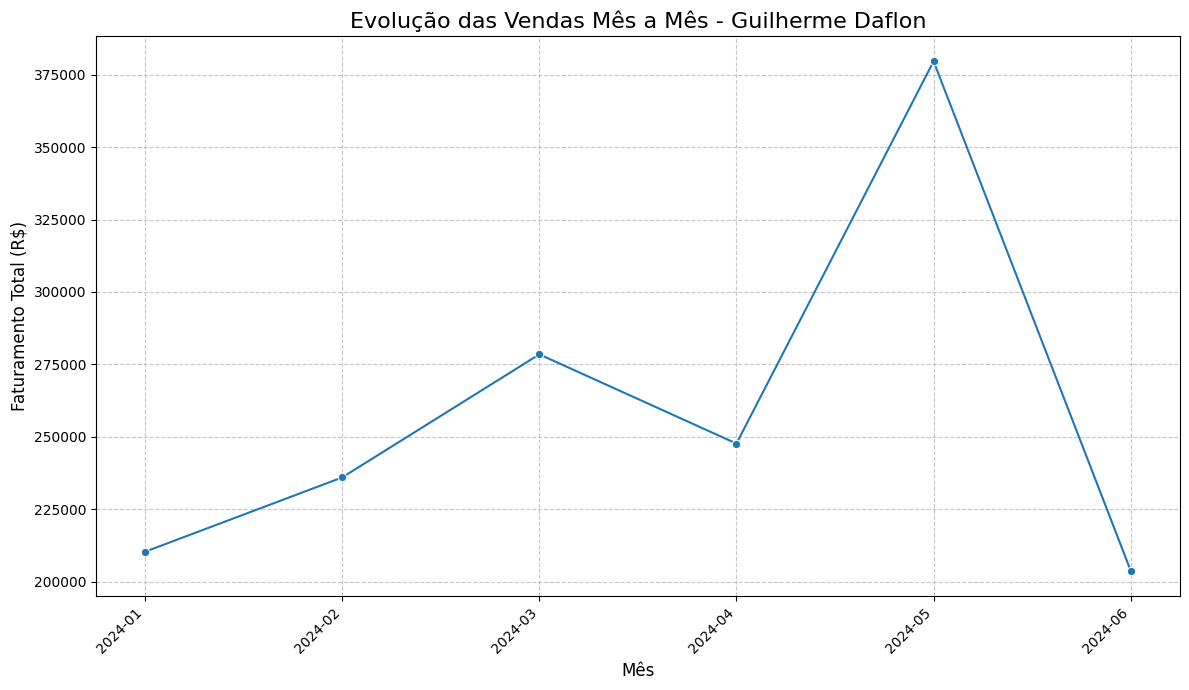

In [18]:
# 3. Gere um gráfico de linha mostrando a evolução das vendas mês a mês.
plt.figure(figsize=(12, 7))
sns.lineplot(x='Mes', y='Faturamento_Total', data=faturamento_por_mes, marker='o', palette='viridis')
plt.title('Evolução das Vendas Mês a Mês - Guilherme Daflon', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo X para melhor visualização
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

### Tarefa 3: Distribuição da Quantidade Vendida

Vamos visualizar a proporção de itens vendidos por categoria de produto.

In [19]:
# 1. Agrupe os dados por Produto e calcule a soma da Quantidade vendida.
quantidade_por_produto = df.groupby('Produto')['Quantidade'].sum().reset_index()

print("Quantidade total vendida por produto:")
display(quantidade_por_produto)

Quantidade total vendida por produto:


,Produto,Quantidade
0,Fone de Ouvido,201
1,Monitor,178
2,Notebook,196
3,Smartphone,313


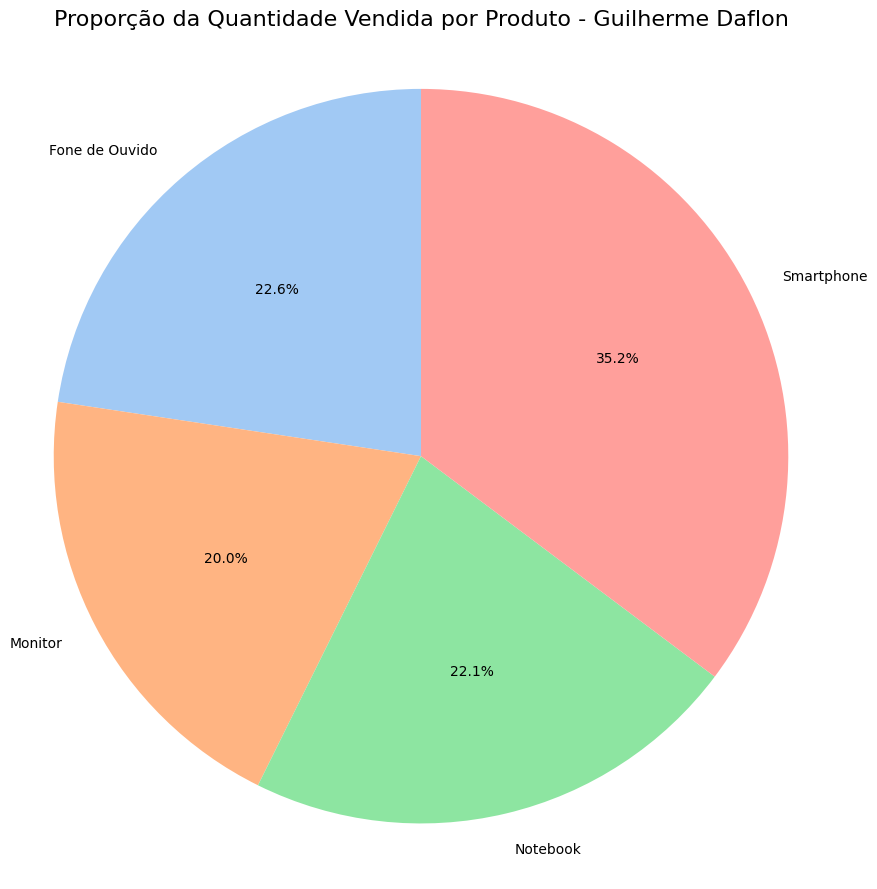

In [20]:
# 2. Gere um gráfico de pizza mostrando a proporção de itens vendidos por Produto.
plt.figure(figsize=(9, 9))
plt.pie(quantidade_por_produto['Quantidade'],
        labels=quantidade_por_produto['Produto'],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('pastel')) # Usando uma paleta de cores do seaborn
plt.title('Proporção da Quantidade Vendida por Produto - Guilherme Daflon', fontsize=16)
plt.axis('equal') # Garante que o gráfico de pizza seja circular.
plt.tight_layout()
plt.show()